# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [ ]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 45.3 MB/s eta 0:00:00


# Important Libraries

In [ ]:
import optuna
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pytorch_tabnet.metrics import Metric
import joblib
import os
import gc

# Data Loading

In [ ]:
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

Loading data...
Data is loaded


In [ ]:
# 30 bands
aef_features = [
    "AEF_B37_mean", "AEF_B37_min", "AEF_B37_max", "AEF_B37_std",
    "AEF_B39_mean", "AEF_B39_min", "AEF_B39_max", "AEF_B39_std",
    "AEF_B31_mean", "AEF_B31_min", "AEF_B31_max", "AEF_B31_std",
    "AEF_B21_mean", "AEF_B21_min", "AEF_B21_max", "AEF_B21_std",
    "AEF_B63_mean", "AEF_B63_min", "AEF_B63_max", "AEF_B63_std",
    "AEF_B55_mean", "AEF_B55_min", "AEF_B55_max", "AEF_B55_std",
    "AEF_B3_mean", "AEF_B3_min", "AEF_B3_max", "AEF_B3_std",
    "AEF_B2_mean", "AEF_B2_min", "AEF_B2_max", "AEF_B2_std",
    "AEF_B9_mean", "AEF_B9_min", "AEF_B9_max", "AEF_B9_std",
    "AEF_B49_mean", "AEF_B49_min", "AEF_B49_max", "AEF_B49_std",
    "AEF_B7_mean", "AEF_B7_min", "AEF_B7_max", "AEF_B7_std",
    "AEF_B45_mean", "AEF_B45_min", "AEF_B45_max", "AEF_B45_std",
    "AEF_B41_mean", "AEF_B41_min", "AEF_B41_max", "AEF_B41_std",
    "AEF_B59_mean", "AEF_B59_min", "AEF_B59_max", "AEF_B59_std",
    "AEF_B19_max", "AEF_B19_mean", "AEF_B19_min", "AEF_B19_std",
    "AEF_B15_max", "AEF_B15_mean", "AEF_B15_min", "AEF_B15_std",
    "AEF_B43_mean", "AEF_B43_min", "AEF_B43_max", "AEF_B43_std",
    "AEF_B60_mean", "AEF_B60_min", "AEF_B60_max", "AEF_B60_std",
    "AEF_B22_mean", "AEF_B22_min", "AEF_B22_max", "AEF_B22_std",
    "AEF_B47_mean", "AEF_B47_min", "AEF_B47_max", "AEF_B47_std",
    "AEF_B56_mean", "AEF_B56_min", "AEF_B56_max", "AEF_B56_std",
    "AEF_B23_mean", "AEF_B23_min", "AEF_B23_max", "AEF_B23_std",
    "AEF_B17_mean", "AEF_B17_min", "AEF_B17_max", "AEF_B17_std",
    "AEF_B4_mean", "AEF_B4_min", "AEF_B4_max", "AEF_B4_std",
    "AEF_B32_mean", "AEF_B32_min", "AEF_B32_max", "AEF_B32_std",
    "AEF_B33_mean", "AEF_B33_min", "AEF_B33_max", "AEF_B33_std",
    "AEF_B51_mean", "AEF_B51_min", "AEF_B51_max", "AEF_B51_std",
    "AEF_B38_mean", "AEF_B38_min", "AEF_B38_max", "AEF_B38_std",
    "AEF_B8_mean", "AEF_B8_min", "AEF_B8_max", "AEF_B8_std",
    "AEF_B16_min", "AEF_B16_mean", "AEF_B16_max", "AEF_B16_std",
]
len(aef_features)
df1 = df[aef_features + ["height"] + ["age"]]
df1.head()

,AEF_B37_mean,AEF_B37_min,AEF_B37_max,AEF_B37_std,AEF_B39_mean,AEF_B39_min,AEF_B39_max,AEF_B39_std,AEF_B31_mean,AEF_B31_min,...,AEF_B8_mean,AEF_B8_min,AEF_B8_max,AEF_B8_std,AEF_B16_min,AEF_B16_mean,AEF_B16_max,AEF_B16_std,height,age
0,0.025343,-0.062991,0.119093,0.027880,-0.102521,-0.160000,-0.022207,0.019137,0.039103,-0.022207,...,0.245116,0.141730,0.374256,0.051039,0.124567,0.249291,0.318893,0.030433,14.0,5.0
1,0.027220,-0.051734,0.119093,0.024248,-0.102631,-0.172795,0.019931,0.030703,0.074555,-0.022207,...,0.277353,0.192910,0.374256,0.031892,0.032541,0.213840,0.292872,0.035581,14.0,5.0
2,0.069647,0.022207,0.147697,0.027957,-0.100094,-0.160000,-0.013841,0.023878,0.044059,-0.017778,...,0.267692,0.172795,0.346021,0.038515,0.098424,0.204076,0.284444,0.036817,4.0,2.0
3,0.083894,0.022207,0.147697,0.026381,-0.112516,-0.186082,0.000062,0.029761,0.051031,-0.017778,...,0.279576,0.199862,0.393695,0.030147,0.084214,0.189975,0.259900,0.036388,4.0,2.0
4,0.032119,-0.012057,0.113741,0.027763,-0.116919,-0.166336,-0.044844,0.021614,0.043653,-0.015748,...,0.237726,0.166336,0.327812,0.032873,0.093564,0.246017,0.292872,0.030046,14.0,5.0


In [ ]:
# 20 bands

aef_features = [
    "AEF_B37_mean", "AEF_B37_min", "AEF_B37_max", "AEF_B37_std",
    "AEF_B39_mean", "AEF_B39_min", "AEF_B39_max", "AEF_B39_std",
    "AEF_B31_mean", "AEF_B31_min", "AEF_B31_max", "AEF_B31_std",
    "AEF_B21_mean", "AEF_B21_min", "AEF_B21_max", "AEF_B21_std",
    "AEF_B63_mean", "AEF_B63_min", "AEF_B63_max", "AEF_B63_std",
    "AEF_B55_mean", "AEF_B55_min", "AEF_B55_max", "AEF_B55_std",
    "AEF_B3_mean", "AEF_B3_min", "AEF_B3_max", "AEF_B3_std",
    "AEF_B2_mean", "AEF_B2_min", "AEF_B2_max", "AEF_B2_std",
    "AEF_B9_mean", "AEF_B9_min", "AEF_B9_max", "AEF_B9_std",
    "AEF_B49_mean", "AEF_B49_min", "AEF_B49_max", "AEF_B49_std",
    "AEF_B7_mean", "AEF_B7_min", "AEF_B7_max", "AEF_B7_std",
    "AEF_B45_mean", "AEF_B45_min", "AEF_B45_max", "AEF_B45_std",
    "AEF_B41_mean", "AEF_B41_min", "AEF_B41_max", "AEF_B41_std",
    "AEF_B59_mean", "AEF_B59_min", "AEF_B59_max", "AEF_B59_std",
    "AEF_B19_max", "AEF_B19_mean", "AEF_B19_min", "AEF_B19_std",
    "AEF_B15_max", "AEF_B15_mean", "AEF_B15_min", "AEF_B15_std",
    "AEF_B43_mean", "AEF_B43_min", "AEF_B43_max", "AEF_B43_std",
    "AEF_B60_mean", "AEF_B60_min", "AEF_B60_max", "AEF_B60_std",
    "AEF_B22_mean", "AEF_B22_min", "AEF_B22_max", "AEF_B22_std",
    "AEF_B47_mean", "AEF_B47_min", "AEF_B47_max", "AEF_B47_std"
]
len(aef_features)
df1 = df[aef_features + ["height"] + ["age"]]
df1.head()

,AEF_B37_mean,AEF_B37_min,AEF_B37_max,AEF_B37_std,AEF_B39_mean,AEF_B39_min,AEF_B39_max,AEF_B39_std,AEF_B31_mean,AEF_B31_min,...,AEF_B22_mean,AEF_B22_min,AEF_B22_max,AEF_B22_std,AEF_B47_mean,AEF_B47_min,AEF_B47_max,AEF_B47_std,height,age
0,0.025343,-0.062991,0.119093,0.027880,-0.102521,-0.160000,-0.022207,0.019137,0.039103,-0.022207,...,0.138101,-0.013841,0.236463,0.039197,0.058896,-0.015748,0.141730,0.029984,14.0,5.0
1,0.027220,-0.051734,0.119093,0.024248,-0.102631,-0.172795,0.019931,0.030703,0.074555,-0.022207,...,0.145424,-0.044844,0.214133,0.035057,0.094359,0.006151,0.172795,0.025654,14.0,5.0
2,0.069647,0.022207,0.147697,0.027957,-0.100094,-0.160000,-0.013841,0.023878,0.044059,-0.017778,...,0.118976,-0.000984,0.192910,0.038389,0.079845,-0.010396,0.160000,0.037704,4.0,2.0
3,0.083894,0.022207,0.147697,0.026381,-0.112516,-0.186082,0.000062,0.029761,0.051031,-0.017778,...,0.121616,0.059116,0.192910,0.022394,0.096189,0.017778,0.172795,0.032094,4.0,2.0
4,0.032119,-0.012057,0.113741,0.027763,-0.116919,-0.166336,-0.044844,0.021614,0.043653,-0.015748,...,0.139821,0.055363,0.199862,0.021014,0.074233,0.019931,0.135886,0.021834,14.0,5.0


In [ ]:
df1 = df1.loc[df["age"] != 5].dropna(axis=0)

y = df1["height"]
X = df1.drop(columns=["age", "height"], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")


Datasets are read! X_train shape: (284117, 120), X_test shape: (50139, 120), X_val shape: (58987, 120)


In [ ]:
del df, df1, X, y

gc.collect()

0

# Tabnet Hyper parameter optimization

In [ ]:
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.astype(np.float32).reshape(-1, 1)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.astype(np.float32).reshape(-1, 1)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.astype(np.float32).reshape(-1, 1)

In [ ]:
def objective_standard_reg(trial):
    # Hyperparameter Space
    n_d = trial.suggest_int('n_d', 16, 64, step=16)
    n_a = n_d # Keep equal
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize Model
    reg = TabNetRegressor(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":20, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0,
        device_name='cuda'
    )

    # Train Model (Using all data, passing validation set)
    reg.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers= 12
    )

    # Evaluate
    preds = reg.predict(X_val_np)
    rmse = np.sqrt(mean_squared_error(y_val_np, preds))

    return rmse

print("\nStarting Optuna Optimization for Standard TabNet Height Model...")

study_std = optuna.create_study(direction='minimize')

study_std.optimize(objective_standard_reg, n_trials=50)

print("\nBest Parameters Found:")
for key, value in study_std.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-17 11:35:42,126] A new study created in memory with name: no-name-716494ed-4370-45ee-a095-91747f679568



Starting Optuna Optimization for Standard TabNet Height Model...
Stop training because you reached max_epochs = 100 with best_epoch = 97 and best_valid_rmse = 2.57045


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 11:46:34,137] Trial 0 finished with value: 2.570454045720263 and parameters: {'n_d': 16, 'n_steps': 6, 'gamma': 1.249380535412036, 'lambda_sparse': 0.0004796895008187476, 'lr': 0.03605102473875336}. Best is trial 0 with value: 2.570454045720263.


Stop training because you reached max_epochs = 100 with best_epoch = 97 and best_valid_rmse = 1.88725


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 11:58:56,241] Trial 1 finished with value: 1.8872511213316714 and parameters: {'n_d': 64, 'n_steps': 7, 'gamma': 1.0744612250498515, 'lambda_sparse': 1.659122583899891e-05, 'lr': 0.032005713584540824}. Best is trial 1 with value: 1.8872511213316714.


...

Stop training because you reached max_epochs = 100 with best_epoch = 91 and best_valid_rmse = 1.76952


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 18:48:43,933] Trial 48 finished with value: 1.7695150143044842 and parameters: {'n_d': 64, 'n_steps': 3, 'gamma': 1.1937031636593547, 'lambda_sparse': 0.0005757407833325443, 'lr': 0.027285892766757965}. Best is trial 42 with value: 1.6946201580777842.


Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_valid_rmse = 1.91596


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 18:56:10,915] Trial 49 finished with value: 1.9159636106440048 and parameters: {'n_d': 48, 'n_steps': 3, 'gamma': 1.065803597005789, 'lambda_sparse': 0.00032005466418914, 'lr': 0.012801078780092715}. Best is trial 42 with value: 1.6946201580777842.



Best Parameters Found:
  n_d: 64
  n_steps: 3
  gamma: 1.2199359671333618
  lambda_sparse: 0.006094688679667799
  lr: 0.011719814582518551


**Best params**

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.2199359671333618
#   lambda_sparse: 0.006094688679667799
#   lr: 0.011719814582518551

In [ ]:
# 30
Tabnet_height = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 3,
    gamma= 1.2199359671333618,
    lambda_sparse= 0.006094688679667799,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.011719814582518551),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_height.fit(
    X_train=X_train_np, y_train=y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 27.28847| valid_rmse: 3.86652 |  0:00:06s
epoch 1  | loss: 8.59668 | valid_rmse: 3.80441 |  0:00:12s
epoch 2  | loss: 8.00818 | valid_rmse: 3.69833 |  0:00:17s
epoch 3  | loss: 7.55738 | valid_rmse: 3.55667 |  0:00:23s
epoch 4  | loss: 7.20107 | valid_rmse: 3.36037 |  0:00:28s
epoch 5  | loss: 6.81174 | valid_rmse: 3.14815 |  0:00:34s
epoch 6  | loss: 6.44687 | valid_rmse: 3.01771 |  0:00:40s
epoch 7  | loss: 6.15484 | valid_rmse: 2.81355 |  0:00:45s
epoch 8  | loss: 5.81543 | valid_rmse: 2.75767 |  0:00:51s
epoch 9  | loss: 5.53112 | valid_rmse: 2.62261 |  0:00:56s
epoch 10 | loss: 5.2171  | valid_rmse: 2.52288 |  0:01:02s
epoch 11 | loss: 4.89685 | valid_rmse: 2.46691 |  0:01:07s
epoch 12 | loss: 4.73497 | valid_rmse: 2.34425 |  0:01:12s
epoch 13 | loss: 4.49579 | valid_rmse: 2.3059  |  0:01:18s
epoch 14 | loss: 4.25053 | valid_rmse: 2.25005 |  0:01:23s
epoch 15 | loss: 4.05028 | valid_rmse: 2.23691 |  0:01:29s
epoch 16 | loss: 3.89629 | valid_rmse: 2.16517 |  0:01:3

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
# 20
Tabnet_height = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 3,
    gamma= 1.2199359671333618,
    lambda_sparse= 0.006094688679667799,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.011719814582518551),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_height.fit(
    X_train=X_train_np, y_train=y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 19.44306| valid_rmse: 3.97791 |  0:00:06s
epoch 1  | loss: 8.98941 | valid_rmse: 3.9485  |  0:00:12s
epoch 2  | loss: 8.38534 | valid_rmse: 3.7888  |  0:00:18s
epoch 3  | loss: 7.98521 | valid_rmse: 3.65029 |  0:00:24s
epoch 4  | loss: 7.6966  | valid_rmse: 3.48362 |  0:00:30s
epoch 5  | loss: 7.42931 | valid_rmse: 3.36758 |  0:00:36s
epoch 6  | loss: 7.15059 | valid_rmse: 3.2231  |  0:00:42s
epoch 7  | loss: 6.81432 | valid_rmse: 3.01333 |  0:00:48s
epoch 8  | loss: 6.49465 | valid_rmse: 2.90949 |  0:00:54s
epoch 9  | loss: 6.31345 | valid_rmse: 2.7848  |  0:00:59s
epoch 10 | loss: 5.88737 | valid_rmse: 2.64414 |  0:01:05s
epoch 11 | loss: 5.75985 | valid_rmse: 2.56022 |  0:01:11s
epoch 12 | loss: 5.41971 | valid_rmse: 2.46628 |  0:01:17s
epoch 13 | loss: 5.21958 | valid_rmse: 2.42464 |  0:01:23s
epoch 14 | loss: 5.03976 | valid_rmse: 2.37384 |  0:01:29s
epoch 15 | loss: 4.84376 | valid_rmse: 2.33686 |  0:01:35s
epoch 16 | loss: 4.55785 | valid_rmse: 2.2877  |  0:01:4

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 1.505
Final Tabnet Model MAE: 1.048


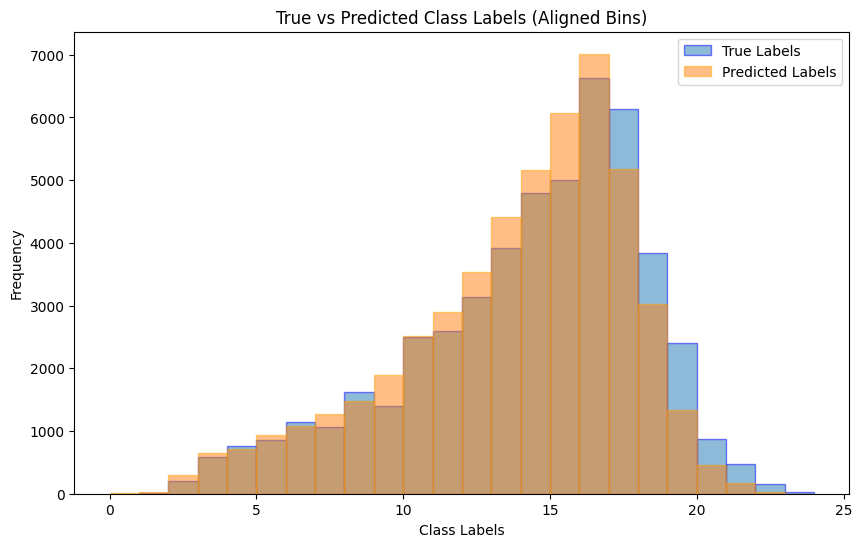

In [ ]:
# 30
# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_height.predict(X_test_np)

rmse_final = np.sqrt(mean_squared_error(y_test_np, y_pred_final))
mae_final = mean_absolute_error(y_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 25, 1)

plt.hist(y_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()


Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 1.642
Final Tabnet Model MAE: 1.154


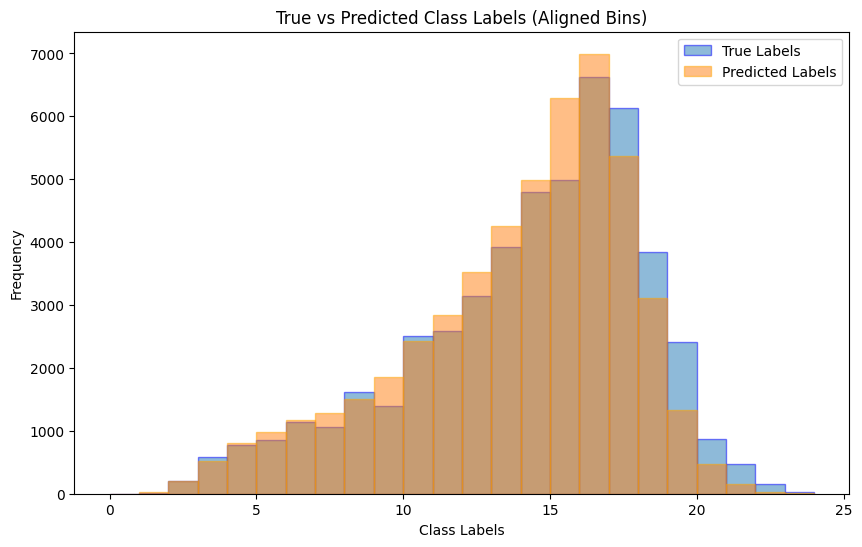

In [ ]:
#20
# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_height.predict(X_test_np)

rmse_final = np.sqrt(mean_squared_error(y_test_np, y_pred_final))
mae_final = mean_absolute_error(y_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 25, 1)

plt.hist(y_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()